## What is this notebook for?

Currently, working with `dea-tools` outside of the sandbox is challenging. Work is happening to enable the `dea-tools` package to operate as an independant python package without datacube/odc dependencies (thanks Robbi!). But, in order to test this work, the package should be installed in it's own, clean environment to make sure it doesn't cause **CHAOS**. 

As a flow-on effect of working in a different environment, users would either need to also install datacube (which is complex) OR, work with `odc-stac` instead, which doesn't require the end user to get their own datacube up and running. This notebook is a first pass at demonstrating using `odc-stac` as a substitute for the datacube, so that a user can run the independant version of `dea-tools`.

If this works, it is a demonstration of a sandbox-independant workflow that could be replicated on anyone's device.

Note that to run this notebook you will need to have used `pip` or `uv` to set up a new virtual envionment, and then installed the required packages. Please see the requirements.txt file for required packages.

In [9]:
from odc.stac import configure_rio, stac_load
import pandas
import xarray
import numpy as np
import dask.distributed
import geopandas as gpd
import dask.distributed
import dask.utils

from pystac_client import Client as StacClient
import IPython.display as display

# dea-tools
from dea_tools.bandindices import calculate_indices

In [10]:
def convert_bounds(bbox, invert_y=False):
    """
    Helper method for changing bounding box representation to leaflet notation

    ``(lon1, lat1, lon2, lat2) -> ((lat1, lon1), (lat2, lon2))``
    """
    x1, y1, x2, y2 = bbox
    if invert_y:
        y1, y2 = y2, y1
    return ((y1, x1), (y2, x2))

In [11]:
client = dask.distributed.Client()

configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
    client=client
)


/home/ubuntu/repos/dea-notebooks/dea-tools-test/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33987 instead
  warnings.warn(


In [12]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:33987/status,
Dashboard: http://127.0.0.1:33987/status,Workers: 2
Total threads: 2,Total memory: 3.78 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33319,Workers: 2
Dashboard: http://127.0.0.1:33987/status,Total threads: 2
Started: Just now,Total memory: 3.78 GiB
Comm: tcp://127.0.0.1:42363,Total threads: 1
Dashboard: http://127.0.0.1:46385/status,Memory: 1.89 GiB
Nanny: tcp://127.0.0.1:34695,


In [13]:
catalog = StacClient.open("https://explorer.dea.ga.gov.au/stac")

In [14]:
lat = -35.5200
lon = 144.0000
buffer = 0.02
bbox = (lon - buffer, lat - buffer, lon + buffer, lat + buffer)

start_date = '2024-01-01'
end_date = '2024-06-30'

# datacube products = odc-stac collections
collections = ["ga_ls8c_ard_3"]
# datacube measurements = odc-stac bands
bands = ["nbart_blue", "nbart_green", "nbart_red", "nbart_nir"]

resolution = 30
crs= "EPSG:3577"

print(bbox)

(143.98, -35.540000000000006, 144.02, -35.5)


In [15]:
query = catalog.search(
    collections=collections,
    datetime=f"{start_date}/{end_date}",
    bbox = bbox
)
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 46 datasets


In [16]:
ds = stac_load(
    items,
    bands=bands,
    crs=crs,
    resolution=resolution,
    groupby="solar_day",
    bbox=bbox,
)

ds

<xarray.Dataset> Size: 8MB
Dimensions:      (y: 159, x: 135, time: 23)
Coordinates:
  * y            (y) float64 1kB -3.929e+06 -3.929e+06 ... -3.933e+06 -3.933e+06
  * x            (x) float64 1kB 1.083e+06 1.083e+06 ... 1.087e+06 1.087e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 184B 2024-01-01T00:08:58.232955 ... 20...
Data variables:
    nbart_blue   (time, y, x) float32 2MB 747.0 742.0 ... 1.209e+03 1.309e+03
    nbart_green  (time, y, x) float32 2MB 953.0 953.0 ... 1.284e+03 1.337e+03
    nbart_red    (time, y, x) float32 2MB 1.152e+03 1.151e+03 ... 1.359e+03
    nbart_nir    (time, y, x) float32 2MB 2.153e+03 2.122e+03 ... 3.418e+03

In [19]:
ds_ndvi = calculate_indices(ds,
                               index='NDVI',
                               drop=True,
                               inplace=True,
                               collection='ga_ls_3')

Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir']


In [20]:
ds_ndvi

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 159, x: 135, time: 23)
Coordinates:
  * y            (y) float64 1kB -3.929e+06 -3.929e+06 ... -3.933e+06 -3.933e+06
  * x            (x) float64 1kB 1.083e+06 1.083e+06 ... 1.087e+06 1.087e+06
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 184B 2024-01-01T00:08:58.232955 ... 20...
Data variables:
    NDVI         (time, y, x) float32 2MB 0.3029 0.2967 0.269 ... 0.4209 0.431

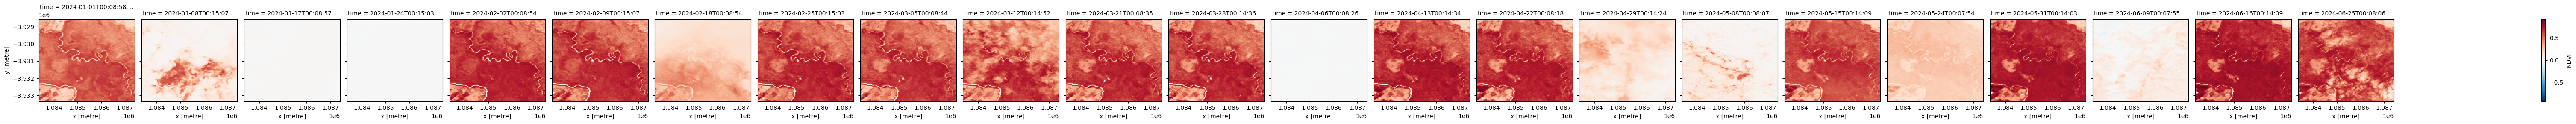

In [21]:
ds_ndvi.NDVI.plot(col='time', col_wrap=5)